# Generate Data

This notebook is used to prototype the generate_data function, used to generate all scenarios of use of the algorithm.

---

## Imports & Config

In [1]:
from numpy.ma.core import swapaxes

# Jax configuration
USE_JIT = False
USE_X64 = True
DEBUG_NANS = False
VERBOSE = False

In [2]:
# Standard library imports
import os
os.environ['JAX_ENABLE_X64'] = str(USE_X64).lower()

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [3]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)

In [4]:
from typing import Tuple
import math
import jax.random as jr
import jax.numpy as jnp
from jax import vmap, jit, Array
from jax.tree_util import tree_map_with_path, GetAttrKey, tree_unflatten, tree_flatten
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import equinox as eqx
import numpy as np

In [5]:
from kernax import BlockKernel, BlockDiagKernel, BatchKernel, WhiteNoiseKernel, BlockDiagKernel, FeatureKernel
from MagmaClustPy.custom_kernels import RBFKernel
from MagmaClustPy.utils import compute_mapping

INFO:2026-02-04 18:42:49,294:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/miniconda3/envs/MagmaClustPy/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
2026-02-04 18:42:49,294 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/miniconda3/envs/MagmaClustPy/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


---

## Generate master function

In [6]:
def compute_priors(grid_size: int, dim: int, feat:int, input_range: tuple[int, int],
                   output_range: tuple[int, int]) -> dict[str, tuple[float, float]]:
	"""
	Compute reasonable prior bounds for GP hyperparameters.

	Args:
	    grid_size: Number of points per dimension
	    dim: Input dimensionality
	    input_range: (min, max) values for input components
	    output_range: (min, max) values for output components

	Returns:
	    Dictionary with prior bounds for 'length_scale', 'variance', 'value' (noise)
	"""
	# Computes spans
	input_span = input_range[1] - input_range[0]
	output_span = output_range[1] - output_range[0]

	# Smallest possible distance between two points in the grid, when only one dimension differs
	min_length_scale = (input_span / (grid_size - 1)) * 4  # Reasonable min distance

	# Average square distance between two points in an hypercube of dimension I
	avg_sq_dist = input_span ** 2 * dim / 6
	max_length_scale = math.sqrt(avg_sq_dist) / grid_size * 16  # Reasonable max distance

	if feat == 1:
		length_scale_prior = (min_length_scale, max_length_scale)
		length_scale_u_prior = (min_length_scale, max_length_scale)  # Should be useless
	else:  # Multi-feature means we have 3 distinct length scales that are summed, so we reduce their ranges
		length_scale_prior = (min_length_scale/4, max_length_scale/4)
		length_scale_u_prior = (min_length_scale/2, max_length_scale/2)

	# Variance prior based on output span
	variance_min = 0.1 * output_span
	variance_max = 0.5 * output_span

	if feat == 1:
		variance_prior = (variance_min, variance_max)
	else:  # Multi-feature means we have 2 distinct variances that are multiplied, so we reduce their ranges
		variance_prior = (jnp.sqrt(variance_min), jnp.sqrt(variance_max))

	# Noise prior based on output span
	noise_min = 0.0005 * output_span
	noise_max = 0.001 * output_span
	noise_prior = (noise_min, noise_max)

	return {
		'length_scale': length_scale_prior,
		'length_scale_u': length_scale_u_prior,
		'_unconstrained_length_scale': length_scale_prior,
		'_unconstrained_length_scale_u': length_scale_u_prior,
		'variance': variance_prior,
		'_unconstrained_variance': variance_prior,
		'value': noise_prior,
		'_unconstrained_value': noise_prior,
		'noise': noise_prior,
		'_unconstrained_noise': noise_prior
	}

In [7]:
compute_priors(grid_size=100, dim=1, feat=1, input_range=(-50, 50), output_range=(-10, 10))

{'length_scale': (4.040404040404041, 6.531972647421809),
 'length_scale_u': (4.040404040404041, 6.531972647421809),
 '_unconstrained_length_scale': (4.040404040404041, 6.531972647421809),
 '_unconstrained_length_scale_u': (4.040404040404041, 6.531972647421809),
 'variance': (2.0, 10.0),
 '_unconstrained_variance': (2.0, 10.0),
 'value': (0.01, 0.02),
 '_unconstrained_value': (0.01, 0.02),
 'noise': (0.01, 0.02),
 '_unconstrained_noise': (0.01, 0.02)}

In [8]:
compute_priors(grid_size=100, dim=2, feat=2, input_range=(-50, 50), output_range=(-10, 10))

{'length_scale': (1.0101010101010102, 2.309401076758503),
 'length_scale_u': (2.0202020202020203, 4.618802153517006),
 '_unconstrained_length_scale': (1.0101010101010102, 2.309401076758503),
 '_unconstrained_length_scale_u': (2.0202020202020203, 4.618802153517006),
 'variance': (Array(1.41421356, dtype=float64, weak_type=True),
  Array(3.16227766, dtype=float64, weak_type=True)),
 '_unconstrained_variance': (Array(1.41421356, dtype=float64, weak_type=True),
  Array(3.16227766, dtype=float64, weak_type=True)),
 'value': (0.01, 0.02),
 '_unconstrained_value': (0.01, 0.02),
 'noise': (0.01, 0.02),
 '_unconstrained_noise': (0.01, 0.02)}

In [9]:
def generate_grid(n_points, n_dims, bounds):
    """
    Generate a regular grid in n_dims with n_points along each dimension, bounded by bounds

    Args:
        n_points: Nb point per dimension (granularity of the grid)
        n_dims: Nb of dimensions
        bounds: bounds of values in the grid

    Returns:
        Un array de shape (n_points**n_dims, n_dims) contenant toutes les combinaisons
    """
    axis = jnp.linspace(bounds[0], bounds[1], n_points)

    grids = jnp.meshgrid(*([axis] * n_dims), indexing='ij')

    return jnp.stack(grids, axis=-1).reshape(-1, n_dims)

In [10]:
def build_kernels(
		T: int,
		F: int,
		O: int,
		K: int,
		feature_hps: bool = False,
		shared_output_hps: bool = True,
		cluster_hps: bool = False,
		shared_task_hps: bool = True,
		shared_inputs_in_features: bool = True,
		shared_inputs_in_tasks: bool = True):
	"""
	Build mean and task kernels for data generation based on specified hyperparameter structure.
	
	This function constructs appropriate kernel hierarchies depending on the number of features,
	outputs, clusters, and whether hyperparameters should be shared across these dimensions.
	
	Args:
		F: Number of features
		O: Dimension of output points
		K: Number of clusters
		feature_hps: Whether features have distinct hyperparameters
		shared_output_hps: Whether output dimensions share hyperparameters
		cluster_hps: Whether clusters have distinct hyperparameters
		shared_task_hps: Whether tasks share hyperparameters
		shared_inputs_in_features: Whether all features are observed on the same sampled grid
		shared_inputs_in_tasks: Whether all tasks are observed on the same sampled grid
	
	Returns:
		Tuple of (mean_kernel, task_kernel) configured according to the specified structure
	"""
	# TODO: integrate ARD kernel (but where?)
	if F == 1:
		# Standard SEKernel
		mean_kernel = RBFKernel(length_scale=1., variance=1.)
		task_kernel = RBFKernel(length_scale=1., variance=1.) + WhiteNoiseKernel(1.)
	else:
		# Multi-feature kernel
		mean_kernel = FeatureKernel(length_scale=1.,  length_scale_u=1., variance=1.)
		task_kernel = FeatureKernel(length_scale=1., length_scale_u=1., variance=1.) + WhiteNoiseKernel(1.)

		# feature HP
		if feature_hps:
			mean_bia = eqx.tree_at(lambda k: (k.length_scale, k.length_scale_u, k.variance),
			                       mean_kernel,
			                       (0, None, 0))
			task_bia = eqx.tree_at(lambda k: (k.length_scale, k.length_scale_u, k.variance),
			                       task_kernel.left_kernel,
			                       (0, None, 0))

			# --- wouldn't work as WhiteNoiseKernel doesn't expect to receive two noises
			#task_bia = eqx.tree_at(lambda k: (k.left_kernel.length_scale, k.left_kernel.length_scale_u, k.left_kernel.variance, k.right_kernel.value),
			#                       task_kernel,
			#                       (0, None, 0, 0))

		else:
			mean_bia = None
			task_bia = None

		mean_kernel = BlockKernel(mean_kernel,
		                          nb_blocks=F,
		                          block_in_axes=mean_bia,
		                          block_over_inputs=not shared_inputs_in_features)
		task_kernel = (BlockKernel(task_kernel.left_kernel,
		                           nb_blocks=F,
		                           block_in_axes=task_bia,
		                           block_over_inputs=not shared_inputs_in_features) +
		               BlockDiagKernel(task_kernel.right_kernel,
		                               nb_blocks=F,
		                               block_in_axes=0 if feature_hps else None,
		                               block_over_inputs=not shared_inputs_in_features))

	# multi-output HPs
	if not shared_output_hps:
		mean_kernel = BatchKernel(mean_kernel, batch_size=O, batch_in_axes=0, batch_over_inputs=False)
		task_kernel = BatchKernel(task_kernel, batch_size=O, batch_in_axes=0, batch_over_inputs=False)
	else:
		mean_kernel = BatchKernel(mean_kernel, batch_size=1, batch_in_axes=None, batch_over_inputs=False)
		task_kernel = BatchKernel(task_kernel, batch_size=1, batch_in_axes=None, batch_over_inputs=False)


	# cluster HPs
	if cluster_hps:
		mean_kernel = BatchKernel(mean_kernel, batch_size=K, batch_in_axes=0, batch_over_inputs=False)
		task_kernel = BatchKernel(task_kernel, batch_size=K, batch_in_axes=0, batch_over_inputs=False)
	else:
		mean_kernel = BatchKernel(mean_kernel, batch_size=1, batch_in_axes=None, batch_over_inputs=False)
		task_kernel = BatchKernel(task_kernel, batch_size=1, batch_in_axes=None, batch_over_inputs=False)


	# task HPs
	if shared_task_hps:
		if shared_inputs_in_tasks:
			task_kernel = BatchKernel(task_kernel, batch_size=1, batch_in_axes=None, batch_over_inputs=False)
		else:
			task_kernel = BatchKernel(task_kernel, batch_size=1, batch_in_axes=None, batch_over_inputs=True)
	else:
		if shared_inputs_in_tasks:
			task_kernel = BatchKernel(task_kernel, batch_size=T, batch_in_axes=0, batch_over_inputs=False)
		else:
			task_kernel = BatchKernel(task_kernel, batch_size=T, batch_in_axes=0, batch_over_inputs=True)
	
	return mean_kernel, task_kernel

In [11]:
def initialize_kernel(key, kernel, priors):
    """
    Initialise les hyper-paramètres d'un kernel Equinox arbitraire.
    """

    # 1. Génération de l'arbre de clés (Key Tree)
    # On a besoin d'une sous-clé unique pour chaque feuille du kernel pour garantir
    # l'indépendance statistique.
    leaves, treedef = tree_flatten(kernel)
    keys = jr.split(key, len(leaves))
    key_tree = tree_unflatten(treedef, keys)

    # 2. Helper pour trouver les bornes dans la config
    def get_bounds(name):
        # Cherche d'abord à la racine (ex: input_range)
        if name in priors:
            return priors[name]
        return None

    # 3. Fonction de transformation
    def init_leaf(path, leaf, subkey):
        # Condition A : On ignore ce qui n'est pas un array JAX (int, str, None...)
        # eqx.is_array renvoie True pour jax.Array et numpy array, mais False pour int/float python
        if not eqx.is_array(leaf):
            return leaf

        # Condition B : On vérifie le nom de l'attribut
        # path[-1] est la clé de la feuille courante.
        # Si c'est un attribut de classe, c'est un GetAttrKey.
        if len(path) > 0 and isinstance(path[-1], GetAttrKey):
            param_name = path[-1].name
            bounds = get_bounds(param_name)

            if bounds is not None:
                min_val, max_val = bounds

                # On sample en préservant la shape de la leaf
                # JAX gère automatiquement le broadcasting du min/max si ce sont des scalaires
                return jr.uniform(
                    subkey,
                    shape=leaf.shape,
                    minval=min_val,
                    maxval=max_val
                )

        # Si aucune condition n'est remplie, on renvoie la feuille intacte
        return leaf

    # 4. Exécution du mapping sur le kernel ET l'arbre de clés
    # On passe key_tree comme 3ème argument, tree_map va itérer dessus en parallèle du kernel
    return tree_map_with_path(init_leaf, kernel, key_tree)

In [12]:
@jit
def sample_gp(key, inputs, mean, cov, jitter=jnp.array(1e-3)) -> Array:
	"""
	Sample outputs from a gaussian process given inputs, mean(s) and kernel(s)

	:param key: JAX PRNG key
	:param inputs: the grid on which to sample. Shape (N, I)
	:param mean: the mean(s) of the generative process for each output dim. Shape (N,) or (N, O)
	:param cov: the covariance matrix. Should have shape (N, N) or (O, N, N)

	:return: generated outputs. Shape (N, O)
	"""
	return jr.multivariate_normal(key, mean.T, cov + jnp.eye(cov.shape[-1])*jitter).T

In [13]:
def plot_processes_1D(K, F, O, g, m_p, o_id=0):
	"""
	Plot the mean process of each cluster, for each feature and output dimension, when inputs are 1D

	Clusters are rows, features are columns.
	o_id allows to select which output dimension to plot when O>1. o_id=None plots all output dimensions as separate curves.

	:param K: number of clusters
	:param F: Number of features
	:param O: Number of output dimensions
	:param g: Input grid. Shape (G, 1) where G is grid_size
	:param m_p: Mean processes. Shape (K, F*G, O)
	:param o_id: output dimension to plot. If None, plots all output dimensions as separate curves.
	"""
	# Handle subplot axes indexing - K rows × F columns
	if K == 1 and F == 1:
		fig, ax = plt.subplots(1, 1, figsize=(8, 6))
		axes = [[ax]]
	elif K == 1:
		fig, axes_arr = plt.subplots(1, F, figsize=(4*F, 4))
		axes = [axes_arr if F > 1 else [axes_arr]]
	elif F == 1:
		fig, axes_arr = plt.subplots(K, 1, figsize=(8, 4*K))
		axes = [[ax] for ax in (axes_arr if K > 1 else [axes_arr])]
	else:
		fig, axes = plt.subplots(K, F, figsize=(4*F, 4*K))
		if not isinstance(axes[0], np.ndarray):
			axes = [[ax] for ax in axes]

	grid_size_per_feature = g.shape[0]
	
	for k in range(K):
		for f in range(F):
			# Extract data for this cluster and feature
			start_idx = f * grid_size_per_feature
			end_idx = (f + 1) * grid_size_per_feature
			
			if o_id is None:
				# Plot all output dimensions as separate curves
				for o in range(O):
					data = m_p[k, start_idx:end_idx, o]
					axes[k][f].plot(g[:, 0], data, label=f'Output {o}')
				axes[k][f].legend()
			else:
				# Plot only the selected output dimension
				data = m_p[k, start_idx:end_idx, o_id]
				axes[k][f].plot(g[:, 0], data)
			
			axes[k][f].set_xlabel('Input')
			axes[k][f].set_ylabel('Output')
			axes[k][f].set_title(f'Cluster {k}, Feature {f}')
			axes[k][f].grid(True)
			axes[k][f].set_xlim(-50, 50)
			axes[k][f].set_ylim(-10, 10)

	plt.tight_layout()
	plt.show()

In [14]:
def plot_processes_2D(K, F, O, g, m_p, o_id=0):
	"""
	Plot the mean process of each cluster, for each feature and output dimension, when inputs are 2D

	Clusters are rows, features are columns.
	o_id allows to select which output dimension to plot when O>1. For 3D plots, only one output can be shown at a time.

	:param K: number of clusters
	:param F: Number of features
	:param O: Number of output dimensions
	:param g: Input grid. Shape (G**2, 2) where G is grid_size
	:param m_p: Mean processes. Shape (K, F*G**2, O)
	:param o_id: output dimension to plot (must be an integer for 2D inputs, as 3D plots can only show one output)
	"""
	# Validate o_id for 3D plotting
	if o_id is None:
		raise ValueError("o_id cannot be None for 2D inputs. 3D surface plots require a single output dimension.")
	if not isinstance(o_id, int) or o_id < 0 or o_id >= O:
		raise ValueError(f"o_id must be an integer between 0 and {O-1}")

	# Handle subplot axes indexing - K rows × F columns
	if K == 1 and F == 1:
		fig = plt.figure(figsize=(8, 6))
		ax = fig.add_subplot(111, projection='3d')
		axes = [[ax]]
	elif K == 1:
		fig = plt.figure(figsize=(5*F, 5))
		axes = [[fig.add_subplot(1, F, f+1, projection='3d') for f in range(F)]]
	elif F == 1:
		fig = plt.figure(figsize=(8, 5*K))
		axes = [[fig.add_subplot(K, 1, k+1, projection='3d')] for k in range(K)]
	else:
		fig = plt.figure(figsize=(5*F, 5*K))
		axes = [[fig.add_subplot(K, F, k*F + f + 1, projection='3d') for f in range(F)] for k in range(K)]

	grid_size_per_feature = g.shape[0]
	
	for k in range(K):
		for f in range(F):
			# Extract data for this cluster, feature, and selected output dimension
			start_idx = f * grid_size_per_feature
			end_idx = (f + 1) * grid_size_per_feature
			data = m_p[k, start_idx:end_idx, o_id]
			
			# Plot 3D surface for 2D input
			axes[k][f].plot_trisurf(g[:, 0], g[:, 1], data, cmap='viridis')
			axes[k][f].set_xlabel('Input 1')
			axes[k][f].set_ylabel('Input 2')
			axes[k][f].set_zlabel('Output')
			axes[k][f].set_title(f'Cluster {k}, Feature {f}, Output {o_id}')
			axes[k][f].set_xlim(-50, 50)
			axes[k][f].set_ylim(-50, 50)
			axes[k][f].set_zlim(-10, 10)

	plt.tight_layout()
	plt.show()

In [15]:
def plot_task_means_1D(K, F, O, T, g, m_p, full_i, task_means, mix, o_id=0):
	"""
	Plot the mean process of each cluster with individual tasks overlaid, for 1D inputs
	
	Clusters are rows, features are columns.
	Tasks are plotted on top of their assigned cluster's mean process with transparency.
	
	:param K: number of clusters
	:param F: Number of features
	:param O: Number of output dimensions
	:param T: Number of tasks
	:param g: Input grid. Shape (G, 1) where G is grid_size
	:param m_p: Mean processes. Shape (K, F*G, O)
	:param full_i: Task inputs. Shape (T, F, N, I)
	:param task_means: Task mean values. Shape (T, F*N, O)
	:param mix: Task-to-cluster assignment. Shape (T,)
	:param o_id: output dimension to plot. If None, plots all output dimensions as separate curves.
	"""
	# Handle subplot axes indexing - K rows × F columns
	if K == 1 and F == 1:
		fig, ax = plt.subplots(1, 1, figsize=(8, 6))
		axes = [[ax]]
	elif K == 1:
		fig, axes_arr = plt.subplots(1, F, figsize=(4*F, 4))
		axes = [axes_arr if F > 1 else [axes_arr]]
	elif F == 1:
		fig, axes_arr = plt.subplots(K, 1, figsize=(8, 4*K))
		axes = [[ax] for ax in (axes_arr if K > 1 else [axes_arr])]
	else:
		fig, axes = plt.subplots(K, F, figsize=(4*F, 4*K))
		if not isinstance(axes[0], np.ndarray):
			axes = [[ax] for ax in axes]

	grid_size_per_feature = g.shape[0]
	N = full_i.shape[2]  # Number of points per feature
	
	# Define colors for each output dimension
	colors = plt.cm.tab10(range(O))
	
	for k in range(K):
		for f in range(F):
			# Extract and plot mean process for this cluster and feature
			start_idx = f * grid_size_per_feature
			end_idx = (f + 1) * grid_size_per_feature
			
			if o_id is None:
				# Plot all output dimensions as separate curves
				for o in range(O):
					data = m_p[k, start_idx:end_idx, o]
					axes[k][f].plot(g[:, 0], data, label=f'Mean Process Output {o}', 
					               color=colors[o], linewidth=2, alpha=0.5)
			else:
				# Plot only the selected output dimension
				data = m_p[k, start_idx:end_idx, o_id]
				axes[k][f].plot(g[:, 0], data, label='Mean Process', 
				               color=colors[0], linewidth=2, alpha=0.5)
			
			# Overlay tasks that belong to this cluster
			for t in range(T):
				if mix[t] == k:
					# Extract task inputs and means for this feature
					task_start_idx = f * N
					task_end_idx = (f + 1) * N
					
					task_inputs = full_i[t, f, :, 0]  # Shape (N,)
					task_outputs = task_means[t, task_start_idx:task_end_idx, :]  # Shape (N, O)
					
					if o_id is None:
						# Plot all output dimensions
						for o in range(O):
							axes[k][f].plot(task_inputs, task_outputs[:, o], 
							               color=colors[o], alpha=1, marker='o', linestyle='None',
							               label=f'Task {t} Output {o}' if f == 0 else '')
					else:
						# Plot only the selected output dimension
						axes[k][f].plot(task_inputs, task_outputs[:, o_id], 
						               color=colors[0], alpha=1, marker='o', linestyle='None',
						               label=f'Task {t}' if f == 0 else '')
			
			axes[k][f].set_xlabel('Input')
			axes[k][f].set_ylabel('Output')
			axes[k][f].set_title(f'Cluster {k}, Feature {f}')
			axes[k][f].grid(True)
			axes[k][f].set_xlim(-50, 50)
			axes[k][f].set_ylim(-10, 10)
			
			# Only show legend on the first subplot to avoid clutter
			if k == 0 and f == 0:
				axes[k][f].legend(fontsize=8, loc='best')

	plt.tight_layout()
	plt.show()

In [16]:
key = jr.PRNGKey(42)

In [17]:
def generate_data(
		key, T:int, K:int, F:int, N:int, I:int, O:int, grid_size:int,
		shared_task_hps: bool = True,
		cluster_hps: bool = False,
		feature_hps:bool = False,
		ard_inputs:bool = False,
		shared_output_hps:bool = True,
		shared_inputs_in_tasks: bool = True,
		shared_inputs_in_features: bool = True,
		missing_inputs_ratio:float = 0.,
		missing_output_dim_ratio:float = 0.,
		same_size_clusters:bool = True,
		input_range:Tuple[int, int] = (-50, 50),
		output_range:Tuple[int, int] = (-10, 10),
		priors=None,
):
	"""
	--- PRNG parameters ---
	:param key: `jax.random` PRNG key

	--- Dataset size parameters ---
	:param T: Number of tasks
	:param K: Number of clusters
	:param F: Number of features
	:param N: Number of points for each feature of each task
	:param I: Dimension of input points
	:param O: Dimension of output points

	--- Hyper-parameters options ---
	:param shared_task_hps: Whether tasks share hyper-parameters
	:param cluster_hps: Whether task have cluster-specific hyper-parameters
	:param feature_hps: Whether features share hyper-parameters
	:param ard_inputs: Whether inputs dimensions have different weights for covariance between points
	:param shared_output_hps: Whether outputs dimensions share hyper-parameters

	--- Sampling options ---
	:param grid_size: Grid size along each dimension. Ex: if I=2 and grid_size=10, inputs will be sampled from a regular 2D grid containing 10**2 = 100 points, from [input_range[0], input_range[0]] to [input_range[1], input_range[1]]
	:param shared_inputs_in_tasks: Whether all tasks are observed on the same sampled grid
	:param shared_inputs_in_features: Whether all features are observed on the same sampled grid
	:param missing_inputs_ratio: How much of the input points should be missing in each task (between 0 and 1)
	:param missing_output_dim_ratio: Probability of an output missing a dimension, in multi-output scenarios (between 0 and 1)
	:param same_size_clusters: If True and T is a multiple of K, all clusters will have the same number of tasks. Otherwise, tasks are randomly assigned to clusters.

	--- Configuration parameters ---
	:param input_range: Min and max value for input points (applied to every input dimensions)
	:param output_range: Min and max value for output points (applied to every output dimensions)
	:param priors: Dictionary of prior ranges for hyper-parameters randomisation. If not provided, appropriate priors will be computed based on input/output ranges, input dimension and grid size.

	:return: inputs (Shape (T, F, N**I, I)), outputs (Shape (T, F, N**I, O)), mixture (Shape T, K) and the mean kernel and task kernel used to generate the data
	"""
	assert grid_size**I >= N, f"Cannot sample N={N} points in a grid containing {grid_size**I} points (= {grid_size}^{I})"
	assert I > 1 or not ard_inputs, f"Cannot set ard_inputs={ard_inputs} when having only {I} input dimensions"
	assert O > 1 or shared_output_hps, f"No need to differentiate hyper-parameters for outputs when having only {O} output dimension"
	assert K > 1 or not cluster_hps, f"No need for cluster-specific hyper-parameters when having only {K} cluster"
	assert F > 1 or not feature_hps, f"No need for feature-specific hyper-parameters when having only {F} feature"

	if priors is None:
		priors = compute_priors(grid_size, I, F, input_range, output_range)

	# Step 1: sample the input grid(s)
	grid = generate_grid(grid_size, I, input_range)  # Shape (G, I) where G = grid_size**I
	key, subkey = jr.split(key)
	if shared_inputs_in_tasks:
		if shared_inputs_in_features:
			# The input grid is unique to all tasks and features
			inputs = jr.choice(subkey, grid, (N,), replace=False)  # Shape (N, I)
			mappings = compute_mapping(grid, inputs)  # Shape (N,)

			#inputs = inputs[None, None, :, :]  # Shape (1, 1, N, I)
			#inputs = jnp.broadcast_to(inputs, (T, F, N, I))  # Shape (T, F, N, I)
		else:
			# The input grid is unique to all tasks but varies between features
			inputs = jr.choice(subkey, grid, (F, N), replace=False)  # Shape (F, N, I)
			mappings = vmap(lambda i: compute_mapping(grid, i))(inputs)  # Shape (F, N)

			#inputs = inputs[None, :, :, :]  # Shape (1, F, N, I)
			#inputs = jnp.broadcast_to(inputs, (T, F, N, I))  # Shape (T, F, N, I)
	else:
		if shared_inputs_in_features:
			# The input grid varies between tasks but is shared between features
			inputs = jr.choice(subkey, grid, (T, N), replace=False)  # Shape (T, N, I)
			mappings = vmap(lambda i: compute_mapping(grid, i))(inputs)  # Shape (T, N)

			#inputs = inputs[:, None, :, :]  # Shape (T, 1, N, I)
			#inputs = jnp.broadcast_to(inputs, (T, F, N, I))  # Shape (T, F, N, I)
		else:
			# The input grid varies between tasks and between features within each task
			inputs = jr.choice(subkey, grid, (T, F, N), replace=False)  # Shape (T, F, N, I)
			mappings = vmap(vmap(lambda i: compute_mapping(grid, i)))(inputs)  # Shape (T, F, N)

	# Step 2: build kernels
	mean_kernel, task_kernel = build_kernels(
		T=T,
		F=F,
		O=O,
		K=K,
		feature_hps=feature_hps,
		shared_output_hps=shared_output_hps,
		cluster_hps=cluster_hps,
		shared_task_hps=shared_task_hps,
		shared_inputs_in_features=shared_inputs_in_features,
		shared_inputs_in_tasks=shared_inputs_in_tasks
	)

	# Step 3: randomise HPs
	key, subkey1, subkyey2 = jr.split(key, 3)
	mean_kernel = initialize_kernel(subkey1, mean_kernel, priors)
	# For tasks, we use a much smaller variance
	priors["variance"] = (priors["variance"][0]*0.1, priors["variance"][1]*0.1)
	priors["_unconstrained_variance"] = (priors["_unconstrained_variance"][0]*0.1, priors["_unconstrained_variance"][1]*0.1)
	task_kernel = initialize_kernel(subkyey2, task_kernel, priors)

	# Step 4: sample mean processes for each cluster
	key, subkey = jr.split(key)
	if shared_inputs_in_features:
		sampling_grid = grid
	else:
		sampling_grid = jnp.tile(grid, (F,) + (1,) * (grid.ndim))
	prior_mean = jnp.zeros((grid.shape[0] * F,))

	"""
	if cluster_hps:  # No need to add dimension, as mean_kernel is already batched over clusters
		mean_processes = sample_gp(subkey, sampling_grid, prior_mean, mean_kernel)
	else:
		prior_mean = jnp.broadcast_to(prior_mean, (K,) + prior_mean.shape)
		subkeys = jr.split(subkey, K)
		mean_processes = vmap(lambda k, m: sample_gp(k, sampling_grid, m, mean_kernel))(subkeys, prior_mean)
	"""
	cov = mean_kernel(sampling_grid)
	mean_processes = jnp.swapaxes(jnp.swapaxes(sample_gp(subkey, sampling_grid, prior_mean, cov), 0, 2), 1, 2)  # Shape (K, F*G, O)

	if jnp.any(jnp.isnan(mean_processes)):
		raise RuntimeError(f"NaNs in mean processes ({jnp.count_nonzero(jnp.isnan(mean_processes))/math.prod(mean_processes.shape)*100:.2f}% of values are NaN)")

	# Step 5: assign tasks to clusters
	if same_size_clusters:
		mixture = jnp.argmax(jnp.eye(K)[jnp.arange(T) // K], axis=1)  # Shape (T,)
	else:
		key, subkey = jr.split(key)
		mixture = jnp.argmax(jr.choice(subkey, jnp.eye(K), (T,), replace=True), axis=1)  # Shape (T,)

	# Step 6: Recover means of every task based on their cluster assignment and input grid
	if shared_inputs_in_tasks and shared_inputs_in_features:
		full_inputs = jnp.repeat(jnp.repeat(inputs[None, None, :, :], F, axis=1), T, axis=0).reshape(T, -1, I)
		task_means = mean_processes[mixture].reshape(T, F, -1, O)[:, :, mappings, :].reshape(T, -1, O)
	elif shared_inputs_in_tasks and not shared_inputs_in_features:
		full_inputs = jnp.repeat(inputs[None, :, :], T, axis=0).reshape(T, -1, I)
		task_means = vmap(lambda m_p_t: vmap(lambda m_p_f, map_f: m_p_f[map_f, :])(m_p_t.reshape(F, -1, O), mappings))(mean_processes[mixture]).reshape(T, -1, O)
	elif not shared_inputs_in_tasks and shared_inputs_in_features:
		full_inputs = jnp.repeat(inputs[:, None, :, :], F, axis=1).reshape(T, -1, I)
		task_means = vmap(lambda m_p_t, map_t: m_p_t.reshape(F, -1, O)[:, map_t, :].reshape(-1, O).swapaxes(-1, -2))(mean_processes[mixture], mappings).swapaxes(-1, -2)
	else:
		full_inputs = inputs.reshape(T, -1, I)
		task_means = vmap(lambda m_p_t, map_t: vmap(lambda m_p_f, map_f: m_p_f[map_f, :])(m_p_t.reshape(F, -1, O), map_t))(mean_processes[mixture], mappings).reshape(T, -1, O)

	# Step 6: sample outputs on the input grid(s) using kernel
	key, subkey = jr.split(key)
	subkeys = jr.split(subkey, T)
	full_outputs = vmap(lambda key, i, m, k, mi: sample_gp(key, i, m, k[mi, :, :, :]))(subkeys, full_inputs, task_means, task_kernel(inputs), mixture)

	# full_inputs has shape (T, F*N, I) | full_outputs has shape (T, F*N, O)

	# Step 7a: remove inputs/outputs at random

	# Step 7b: remove output dimensions at random

	# Step 8: return results

	return inputs, mappings, mixture, grid, mean_kernel, task_kernel, mean_processes, full_inputs, task_means, full_outputs

In [18]:
# Check for errors
for sth in (True, False):
	for ch in (True, False):
		for fh in (True, False):
			for I in (1, 2):
				for soh in (True, False):
					for siit in (True, False):
						for siif in (True, False):
							try:
								k = jr.PRNGKey(42)
								generate_data(k, 4, 2, 3, 7, I, 2, 100 if I == 1 else 40, sth, ch, fh, False, soh, siit, siif)
								print(f"OK - {sth}, {ch}, {fh}, {I}, {soh}, {siit}, {siif}")
							except Exception as e:
								print(f"KO - {sth}, {ch}, {fh}, {I}, {soh}, {siit}, {siif} - {e}")

OK - True, True, True, 1, True, True, True
OK - True, True, True, 1, True, True, False
OK - True, True, True, 1, True, False, True
OK - True, True, True, 1, True, False, False
OK - True, True, True, 1, False, True, True
OK - True, True, True, 1, False, True, False
OK - True, True, True, 1, False, False, True
OK - True, True, True, 1, False, False, False
KO - True, True, True, 2, True, True, True - NaNs in mean processes (100.00% of values are NaN)
KO - True, True, True, 2, True, True, False - NaNs in mean processes (100.00% of values are NaN)
KO - True, True, True, 2, True, False, True - NaNs in mean processes (100.00% of values are NaN)
KO - True, True, True, 2, True, False, False - NaNs in mean processes (100.00% of values are NaN)
KO - True, True, True, 2, False, True, True - NaNs in mean processes (75.00% of values are NaN)
KO - True, True, True, 2, False, True, False - NaNs in mean processes (75.00% of values are NaN)
KO - True, True, True, 2, False, False, True - NaNs in mean pro

In [38]:
key, k = jr.split(key)
T=4 ; K=2 ; F=2 ; N=25 ; I=1 ; O=1 ; G=100 ; siit=True ; siif=True
#                     generate_data(k, T, K, F, N,  I, O, G,  sth,   ch,    fh,   ai,   soh,   siit,  siif)
i, map_, mix, g, m_k, t_k, m_p, f_i, t_m, f_o = generate_data(k, T, K, F, N,  I, O, G, True, False, False, False, True, siit, siif)

In [39]:
i.shape

(25, 1)

In [40]:
f_i.shape, f_o.shape

((4, 50, 1), (4, 50, 1))

In [35]:
key, subkey = jr.split(key)
subkeys = jr.split(subkey, T)
tasks = vmap(lambda key, i, m, k, mi: sample_gp(key, i.reshape(-1, I), m, k[mi, :, :, :]))(subkeys, f_i, t_m, t_k(i), mix)
tasks.shape

(4, 25, 1)

IndexError: Too many indices: 3-dimensional array indexed with 4 regular indices.

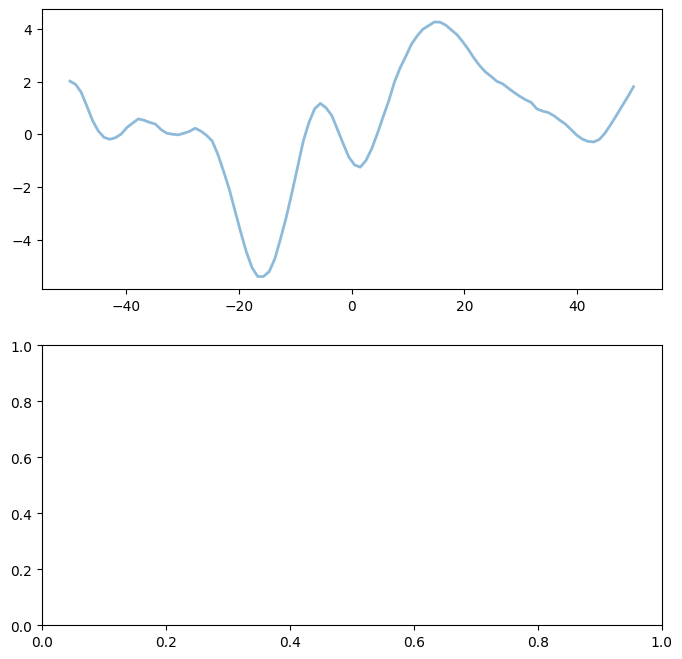

In [36]:
plot_task_means_1D(K, F, O, T, g, m_p, f_i, tasks, mix, o_id=None)

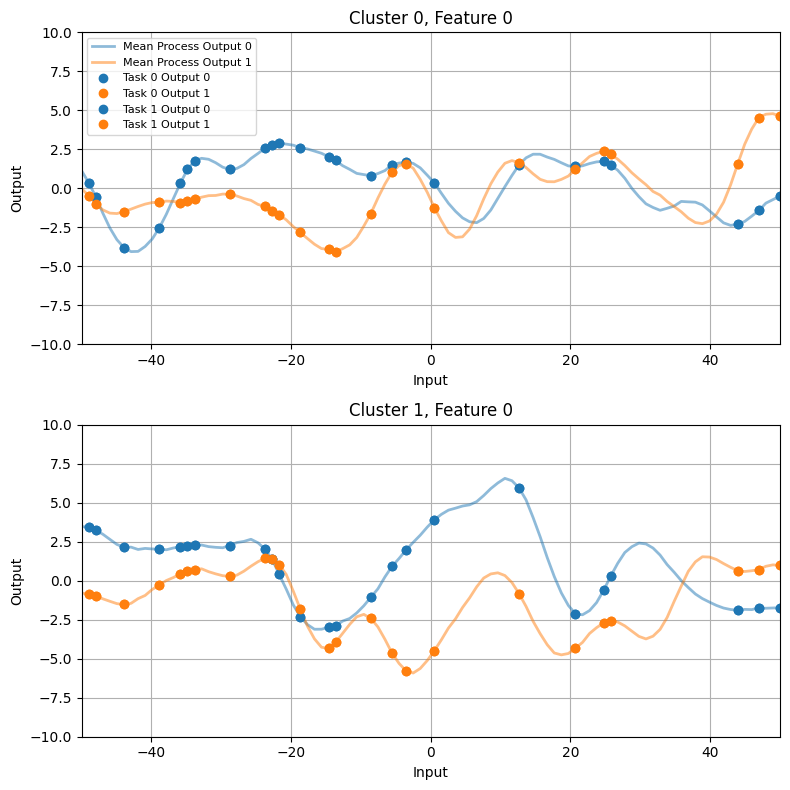

In [96]:
plot_task_means_1D(K, F, O, T, g, m_p, f_i, t_m, mix, o_id=None)

In [41]:
t_k(i).shape

(4, 2, 2, 21, 21)

In [42]:
i.shape

(7, 1)

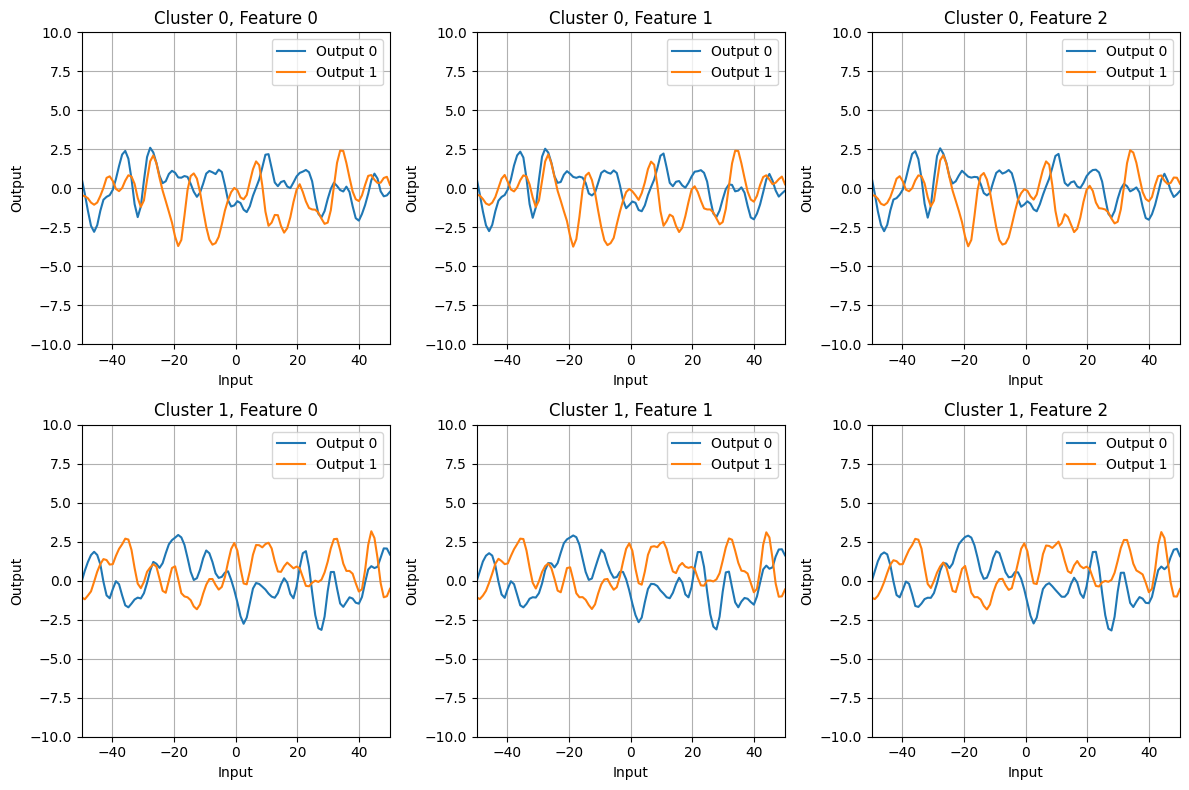

In [43]:
if I == 1:
	plot_processes_1D(K, F, O, g, m_p, o_id=None)
elif I == 2:
	plot_processes_2D(K, F, O, g, m_p)

In [44]:
i, map_

(Array([[ 46.96969697],
        [-13.63636364],
        [-18.68686869],
        [-28.78787879],
        [ -8.58585859],
        [-47.97979798],
        [ 43.93939394]], dtype=float64),
 Array([96, 36, 31, 21, 41,  2, 93], dtype=int32))

In [45]:
t_k(i).shape

(4, 2, 2, 21, 21)

In [46]:
np.asarray(t_k(i)[1, 0])

array([[[1.91626482e+000, 2.09795062e-159, 6.00754174e-187,
         1.20824842e-248, 4.58612460e-134, 0.00000000e+000,
         3.74474114e-001, 9.33345461e-001, 2.09795062e-159,
         6.00754174e-187, 1.20824842e-248, 4.58612460e-134,
         0.00000000e+000, 3.74474114e-001, 9.33345461e-001,
         2.09795062e-159, 6.00754174e-187, 1.20824842e-248,
         4.58612460e-134, 0.00000000e+000, 3.74474114e-001],
        [2.09795062e-159, 1.91626482e+000, 7.38445556e-002,
         1.13377525e-010, 7.38445556e-002, 1.06249648e-051,
         6.16594093e-144, 2.09795062e-159, 9.33345461e-001,
         7.38445556e-002, 1.13377525e-010, 7.38445556e-002,
         1.06249648e-051, 6.16594093e-144, 2.09795062e-159,
         9.33345461e-001, 7.38445556e-002, 1.13377525e-010,
         7.38445556e-002, 1.06249648e-051, 6.16594093e-144],
        [6.00754174e-187, 7.38445556e-002, 1.91626482e+000,
         3.65718277e-005, 3.65718277e-005, 8.09187426e-038,
         3.70654794e-170, 6.00754174e-

In [47]:
vmap(lambda map_t: m_p.reshape(K, F, -1, O)[:, :, map_t, :].reshape(K, -1, O).swapaxes(-1, -2))(map_).shape

(7, 2, 2, 3)

In [48]:
m_p.reshape(K, F, -1, O).shape

(2, 3, 100, 2)

In [49]:
vmap(lambda map_t: m_p.reshape(K, F, -1, O)[:, :, map_t, :].reshape(K, -1, O))(map_).shape

(7, 2, 3, 2)

In [50]:
m_p.reshape(K, F, -1, O)[:, map_, :].reshape(K, F, -1, O).swapaxes(-1, -2).shape

TypeError: cannot reshape array of shape (2, 7, 100, 2) (size 2800) into shape (2, 3, -1, 2) because the product of specified axis sizes (12) does not evenly divide 2800

In [32]:
map_.shape

(3, 7)

In [31]:
m_p.shape

(2, 150, 2)

In [25]:
m.shape

NameError: name 'm' is not defined

In [57]:
m_p.reshape(K, F, -1, O)[:, :, m, :].reshape(K, -1, O)

Array([[[ 1.6243111 ,  0.55679107],
        [ 0.61914295,  0.2791477 ],
        [ 0.09836987, -0.45674232],
        [ 0.2746031 , -0.533147  ],
        [ 0.14218697, -0.42418277],
        [-0.7655076 , -0.49510446],
        [ 0.7528224 ,  0.10385236],
        [ 1.5634654 ,  0.5244517 ],
        [ 0.6178647 ,  0.31535497],
        [ 0.09664965, -0.4563678 ],
        [ 0.21307656, -0.5172871 ],
        [ 0.13718629, -0.35034382],
        [-0.7983085 , -0.49803925],
        [ 0.7870016 ,  0.10532805],
        [ 1.6140413 ,  0.5182095 ],
        [ 0.6274671 ,  0.33631036],
        [ 0.13407424, -0.48143274],
        [ 0.2465589 , -0.5061258 ],
        [ 0.23117474, -0.36893266],
        [-0.85036296, -0.42686623],
        [ 0.8092574 ,  0.02691615]],

       [[-1.3134272 , -1.0976499 ],
        [ 0.00248602, -0.58075035],
        [ 1.6321342 , -0.012393  ],
        [-1.0493237 , -0.06331396],
        [-0.93141365, -0.40841374],
        [ 1.7214587 ,  0.15255803],
        [ 0.2849099 , -0.6

In [79]:
mixture = jr.choice(subkey, jnp.eye(K), (T,), replace=True)

In [85]:
vmap(lambda map_t, mix_t: m_p.reshape(K, F, -1, O)[:, :, map_t, :].reshape(K, -1, O)[jnp.argmax(mix_t)], in_axes=(None, 0))(m, mixture)

Array([[[-1.3134272 , -1.0976499 ],
        [ 0.00248602, -0.58075035],
        [ 1.6321342 , -0.012393  ],
        [-1.0493237 , -0.06331396],
        [-0.93141365, -0.40841374],
        [ 1.7214587 ,  0.15255803],
        [ 0.2849099 , -0.6840257 ],
        [-1.3212905 , -1.0899848 ],
        [ 0.06581706, -0.5939106 ],
        [ 1.631381  , -0.05686253],
        [-1.0596963 , -0.04752779],
        [-0.8743315 , -0.42255652],
        [ 1.7391493 ,  0.13851064],
        [ 0.25971994, -0.7266385 ],
        [-1.2772175 , -1.1113709 ],
        [ 0.06974989, -0.59176075],
        [ 1.6426148 ,  0.02133346],
        [-1.0846027 , -0.03803265],
        [-0.8678969 , -0.39996153],
        [ 1.7352431 ,  0.23482859],
        [ 0.27837253, -0.74460137]],

       [[ 1.6243111 ,  0.55679107],
        [ 0.61914295,  0.2791477 ],
        [ 0.09836987, -0.45674232],
        [ 0.2746031 , -0.533147  ],
        [ 0.14218697, -0.42418277],
        [-0.7655076 , -0.49510446],
        [ 0.7528224 ,  0.1

In [68]:
key, subkey = jr.split(key)
jr.choice(subkey, jnp.eye(K), (T,), replace=True)

Array([[0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.]], dtype=float32)

In [75]:
jnp.eye(K)[jnp.arange(T) // K]

Array([[1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.]], dtype=float32)

In [78]:
jnp.eye(3)[jnp.arange(9) // 3 ]

Array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]], dtype=float32)

In [58]:
m_p.reshape(K, F, -1, O)[:, :, m, :].reshape(K, -1, O).shape

(2, 21, 2)

In [46]:
g[m].shape

(7, 1)

In [44]:
t_k

BatchKernel(
  inner_kernel=BatchKernel(
    inner_kernel=SumKernel(
      left_kernel=BlockKernel(
        inner_kernel=FeatureKernel(
          _unconstrained_length_scale=f32[],
          _unconstrained_length_scale_u=f32[],
          _unconstrained_variance=f32[]
        ),
        nb_blocks=3,
        block_in_axes=FeatureKernel(
          _unconstrained_length_scale=None,
          _unconstrained_length_scale_u=None,
          _unconstrained_variance=None
        ),
        block_over_inputs=None
      ),
      right_kernel=BlockDiagKernel(
        inner_kernel=WhiteNoiseKernel(
          computation_engine=kernax.engines.SafeDiagonalEngine, value=f32[]
        ),
        batch_size=3,
        batch_in_axes=WhiteNoiseKernel(
          computation_engine=kernax.engines.SafeDiagonalEngine, value=None
        ),
        batch_over_inputs=None
      )
    ),
    batch_size=2,
    batch_in_axes=SumKernel(
      left_kernel=BlockKernel(
        inner_kernel=FeatureKernel(
          _un

In [73]:
print(m_k)

BlockFeatureKernel(_unconstrained_length_scale=2.79, _unconstrained_length_scale_u=8.33, _unconstrained_variance=1.65)


In [74]:
m_k

BatchKernel(
  inner_kernel=BatchKernel(
    inner_kernel=BlockKernel(
      inner_kernel=FeatureKernel(
        _unconstrained_length_scale=f32[],
        _unconstrained_length_scale_u=f32[],
        _unconstrained_variance=f32[]
      ),
      nb_blocks=2,
      block_in_axes=FeatureKernel(
        _unconstrained_length_scale=None,
        _unconstrained_length_scale_u=None,
        _unconstrained_variance=None
      ),
      block_over_inputs=None
    ),
    batch_size=1,
    batch_in_axes=BlockKernel(
      inner_kernel=FeatureKernel(
        _unconstrained_length_scale=None,
        _unconstrained_length_scale_u=None,
        _unconstrained_variance=None
      ),
      nb_blocks=2,
      block_in_axes=FeatureKernel(
        _unconstrained_length_scale=None,
        _unconstrained_length_scale_u=None,
        _unconstrained_variance=None
      ),
      block_over_inputs=None
    ),
    batch_over_inputs=None
  ),
  batch_size=3,
  batch_in_axes=BatchKernel(
    inner_kernel=BlockKe

In [75]:
m_k.inner_kernel.inner_kernel.inner_kernel.length_scale

Array(2.7908278, dtype=float32)

In [77]:
m_k.inner_kernel.inner_kernel.inner_kernel.length_scale_u

Array(8.326958, dtype=float32)

In [78]:
m_k.inner_kernel.inner_kernel.inner_kernel.variance

Array(1.6465989, dtype=float32)

In [ ]:
0/0

In [ ]:
# Perform 1000 générations, collect hyper-parameters and whether the generation produced NaNs
# Save HPs and NaN status in a csv file for analysis
with open("hp_nan_analysis.csv", "a") as f:
	# Write header
	f.write("ls_1,ls_2,ls_u,var_1,var_2,has_nans\n")

	for i in range(1000):
		key, k = jr.split(key)
		T=10 ; K=3 ; F=2 ; N=10 ; I=2 ; O=1 ; G=50
		#                     generate_data(k, T, K, F, N,  I, O, G,  sth,   ch,    fh,   ai,   soh,   siit,  siif)
		i, g, m_k, t_k, m_p = generate_data(k, T, K, F, N,  I, O, G, True, False, True, False, True, True, True)

		# Extract HPs
		ls_1, ls_2 = m_k.inner_kernel.inner_kernel.inner_kernel.length_scale
		ls_u = m_k.inner_kernel.inner_kernel.inner_kernel.length_scale_u
		var_1, var_2 = m_k.inner_kernel.inner_kernel.inner_kernel.variance

		# Check for NaNs in mean processes
		has_nans = jnp.any(jnp.isnan(m_p))

		# Save to csv
		f.write(f"{ls_1.item()},{ls_2.item()},{ls_u.item()},{var_1.item()},{var_2.item()},{has_nans}\n")

NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00% of values are NaN)
NaNs in mean processes (100.00%

In [19]:
g.shape, m_k(g).shape, m_p.shape

((100, 1), (3, 1, 200, 200), (3, 200, 1))

In [24]:
a = jr.uniform(key, (10000, 10000))

In [25]:
a.shape

(10000, 10000)

In [31]:
%%timeit

a[None, ...].block_until_ready()

26.9 ms ± 3.07 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [29]:
%%timeit

jnp.repeat(jnp.expand_dims(a, 0), 1, axis=0).block_until_ready()

82.8 ms ± 1.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [32]:
a[None, ...].shape, jnp.repeat(jnp.expand_dims(a, 0), 1, axis=0).shape

((1, 10000, 10000), (1, 10000, 10000))

---